<div align="center"><span style="font-family: Arial; color:#0000FF"><b>
    <span style="font-size: x-large">Métodos Numéricos II</span>
    <br>
    <span style="font-size: large">Segundo de Grado en Matemáticas - Curso 2022/23</span>
    <br>
    <span style="font-size: medium">Facultad de Ciencias de la Universidad de Málaga</span>
    <br>
    <span style="font-size: small">Dpto. de Análisis Matemático, Estadística e Investigación Operativa, y Matemática Aplicada</span>
    <br>
    <span style="font-size: small">Profs. Manuel J. Castro y Francisco J. Palma (Área Conocimiento de Matemática Aplicada)</span>
    <br>
    <span style="font-size: medium; color:#FF0000">Práctica número 11</span>
    </b></span></div>

In [2]:
from algoritmos import *

<div align="left"><span style="font-family: Arial; color:#000000; font-size: medium">
    <span style="color:#FF0000"><b>Ejercicio.</b></span> Se consideran las matrices $A = \left( \begin{array}{ccc} 1 & 2 & -2 \\ 1 & 1 & 1 \\ 2 & 2 & 1 \end{array} \right)$ y $B = \left( \begin{array}{ccc} 2 & -1 & 1 \\ 2 & 2 & 2 \\ -1 & -1 & 2 \end{array} \right)$.
    <br>
    Demostrar que para la primera matriz el método iterativo de Jacobi es convergente, pero el de Gauss-Seidel no lo es, mientras que para la segunda matriz ocurre justamente lo contrario. Escribir las matrices de ambos métodos iterativos para las dos matrices dadas.
    </span></div>

In [3]:
A = array([[1,2,-2],[1,1,1],[2,2,1]])
print("A=\n",A)

#Ca = D^-1(E+F)
D=triu(A)-triu(A,k=1)
invD=inv(D)
E=-tril(A)+D
F=-triu(A)+D
print("\nFa =\n",F)
print("\nEa =\n", E)
print("\ninvDa =\n", invD)

Ca = invD@(E+F)
print("\nCa=\n",Ca)

(autovalores,autovectores)=eig(Ca)
print("\nEl mayor autovalor en módulo de C de Jacobi es ",max(abs(autovalores))," < 1 => Jacobi converge para A")

#Ca = (D-E)^-1 F
Ca=inv(D-E)@F

(autovalores,autovectores)=eig(Ca)
print("\nEl mayor autovalor en módulo de C de Gauss-Seidel es ",max(abs(autovalores))," > 1 => G-S no converge para A")

B = array([[2,-1,1],[2,2,2],[-1,-1,2]])
print("\nB=\n",B)

#Cb = D^-1(E+F)
D=triu(B)-triu(B,k=1)
invD=inv(D)
E=-tril(B)+D
F=-triu(B)+D
print("\nFb =\n",F)
print("\nEb =\n", E)
print("\ninvDb =\n", invD)

Cb = invD@(E+F)
print("\nCb=\n",Cb)

(autovalores,autovectores)=eig(Cb)
print("\nEl mayor autovalor en módulo de C de Jacobi es ",max(abs(autovalores))," > 1 => Jacobi no converge para B")

#Cb = (D-E)^-1 F
Cb=inv(D-E)@F

(autovalores,autovectores)=eig(Cb)
print("\nEl mayor autovalor en módulo de C de Gauss-Seidel es ",max(abs(autovalores))," < 1 => G-S converge para B")


A=
 [[ 1  2 -2]
 [ 1  1  1]
 [ 2  2  1]]

Fa =
 [[ 0 -2  2]
 [ 0  0 -1]
 [ 0  0  0]]

Ea =
 [[ 0  0  0]
 [-1  0  0]
 [-2 -2  0]]

invDa =
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Ca=
 [[ 0. -2.  2.]
 [-1.  0. -1.]
 [-2. -2.  0.]]

El mayor autovalor en módulo de C de Jacobi es  1.0812771377650137e-05  < 1 => Jacobi converge para A

El mayor autovalor en módulo de C de Gauss-Seidel es  2.0  > 1 => G-S no converge para A

B=
 [[ 2 -1  1]
 [ 2  2  2]
 [-1 -1  2]]

Fb =
 [[ 0  1 -1]
 [ 0  0 -2]
 [ 0  0  0]]

Eb =
 [[ 0  0  0]
 [-2  0  0]
 [ 1  1  0]]

invDb =
 [[0.5 0.  0. ]
 [0.  0.5 0. ]
 [0.  0.  0.5]]

Cb=
 [[ 0.   0.5 -0.5]
 [-1.   0.  -1. ]
 [ 0.5  0.5  0. ]]

El mayor autovalor en módulo de C de Jacobi es  1.1180339887498956  > 1 => Jacobi no converge para B

El mayor autovalor en módulo de C de Gauss-Seidel es  0.5  < 1 => G-S converge para B


<div align="left"><span style="font-family: Arial; color:#000000; font-size: medium">
    <span style="color:#FF0000"><b>Ejercicio.</b></span> Se considera la matriz $A = \left( \begin{array}{cccccc} 0 & & & & & \mbox{sim} \\ 1 & 0 \\ 6 & 2 & 0 \\ 0 & 7 & 3 & 0 \\ 0 & 0 & 8 & 4 & 0 \\ 0 & 0 & 0 & 9 & 5 & 0 \end{array} \right)$
    <br>
    Calcular la matriz ortogonal $\Omega$ tal que $B=\Omega^t\,A\,\Omega$ anula el elemento de módulo mayor (y su simétrico) de $A$, de acuerdo con el método de Jacobi para aproximar los autovalores de una matriz simétrica. Comprobar que las matrices $A$ y $B$ tienen la misma norma euclídea y que la contribución a dicha norma en $A$ de los elementos que se anulan, pasa ahora a la diagonal de $B$.
    </span></div>

In [4]:
#A=array([[0,1,6,0,0,0],[1,0,2,7,0,0],[6,2,0,3,8,0],[0,7,3,0,4,9],[0,0,8,4,0,5],[0,0,0,9,5,0]])
#print("A=\n",A)

#B=array([[0,1,6,0,0,0],[1,0,2,7,0,0],[6,2,0,3,8,0],[0,7,3,0,4,0],[0,0,8,4,0,5],[0,0,0,0,5,0]])
#print("\nB=\n",B)


v=array(linspace(1,9,9))
A=zeros((6,6))+diagflat(v[:5],k=1)+diagflat(v[5:],k=2)
A=A+transpose(A)
print("A=\n",A)


#El de mayor módulo es 9, en posición (3,5).
(p,q)=(3,5)

#como aqq-app=0, no se puede hacer tg-1 de eso, luego tenemos que buscar un número tal que
#tg-1(2 tita) = 0, es decir, un tita tal que tg(2 omega) se vaya a infinito
#tg(pi/2)=infinito => podemos tomar tita=pi/4

tita=pi/4

omega = eye(6)
omega[p][p]=omega[q][q]=cos(tita)
omega[p][q]=sin(tita)
omega[q][p]=-sin(tita)

print("\nMatriz omega = \n", omega)


B=transpose(omega)@A@omega
print("\nB = \n", B)

print("\nA y B tiene la misma norma: ||A||E - ||B||E = ",abs(norma_mat(A,"fro")-norma_mat(B,"fro")))

diagB=diag(B)
normaB = norma_vec(diagB,2)

diagA=diag(A)
normaA = norma_vec(diagA,2)

print("\n Comprobación de que la contribución a dicha norma en A de los elementos que se anulan, pasa ahora a la diagonal de B : ", abs(normaB**2-(normaA**2+2*(A[p][q]**2))))

#Se ha hecho con la formula sum(bii^2) = sum(aii^2)+ 2*apq^2


A=
 [[0. 1. 6. 0. 0. 0.]
 [1. 0. 2. 7. 0. 0.]
 [6. 2. 0. 3. 8. 0.]
 [0. 7. 3. 0. 4. 9.]
 [0. 0. 8. 4. 0. 5.]
 [0. 0. 0. 9. 5. 0.]]

Matriz omega = 
 [[ 1.          0.          0.          0.          0.          0.        ]
 [ 0.          1.          0.          0.          0.          0.        ]
 [ 0.          0.          1.          0.          0.          0.        ]
 [ 0.          0.          0.          0.70710678  0.          0.70710678]
 [ 0.          0.          0.          0.          1.          0.        ]
 [ 0.          0.          0.         -0.70710678  0.          0.70710678]]

B = 
 [[ 0.00000000e+00  1.00000000e+00  6.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 1.00000000e+00  0.00000000e+00  2.00000000e+00  4.94974747e+00
   0.00000000e+00  4.94974747e+00]
 [ 6.00000000e+00  2.00000000e+00  0.00000000e+00  2.12132034e+00
   8.00000000e+00  2.12132034e+00]
 [ 0.00000000e+00  4.94974747e+00  2.12132034e+00 -9.00000000e+00
  -7.07106781e-01 -3.744

<div align="left"><span style="font-family: Arial; color:#000000; font-size: medium">
    <span style="color:#FF0000"><b>Ejercicio.</b></span> Una empresa de marketing se plantea la inversión en publicidad para el próximo año. Para ello toma en cuenta los datos de gasto en publicidad y de beneficio en ventas de los últimos 7 años, que están dados por la tabla
\[
\begin{array}{c|c|c|c|c|c|c|c|c}
x &\mbox{Gastos (m€)} & 10 & 25 & 30 & 42 & 45 & 57 & 62 \\ \hline
y &\mbox{Ventas (m€)} & 20 & 30 & 45 & 53 & 62 & 83 & 95
\end{array}
\]
    La empresa va a invertir 65 m€ en publicidad, y quiere saber cuál va a ser el beneficio previsto en ventas (mediante un ajuste por mínimos cuadrados).
    </span></div>

In [13]:
# Generamos los datos.
gastos = array([10, 25, 30, 42, 45, 57, 62])
ventas = array([20, 30, 45, 53, 62, 83, 95])

In [14]:
import matplotlib.pyplot as plt

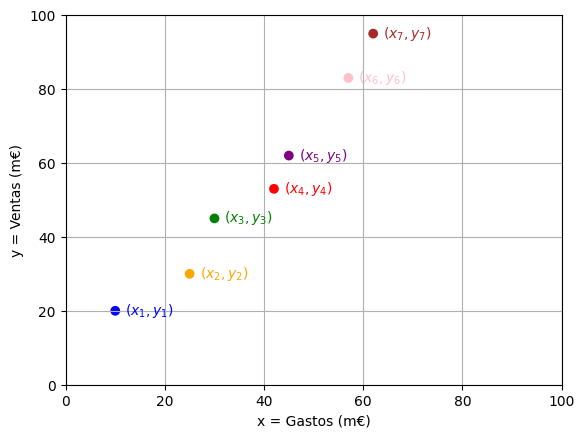

In [15]:
# Representamos los datos.
categories = array([0, 1, 2, 3, 4, 5, 6])
colormap = array(['blue', 'orange', 'green', 'red', 'purple', 'pink', 'brown'])
plt.xlim([0, 100]) # Representar el intervalo del eje X
plt.ylim([0, 100]) # Representar el intervalo del eje Y
plt.grid(True) # Usar o no cuadrilla en el gráfico
plt.scatter(gastos, ventas, c=colormap[categories]) #  Este comando traza un gráfico de dispersión utilizando los valores de gastos como las coordenadas en el eje x y los valores de ventas como las coordenadas en el eje y. El argumento c=colormap[categories] establece el color de cada punto
plt.xlabel('x = Gastos (m€)') # Asignar un nombre al eje X
plt.ylabel('y = Ventas (m€)') # Asignar un nombre al eje Y
for i in range(size(gastos)):
    plt.text(x=gastos[i]+2, y=ventas[i]-1, s="$(x_"+str(i+1)+",y_"+str(i+1)+")$", fontdict=dict(color=colormap[i], size=10))
    # : Este comando agrega un texto al gráfico en las coordenadas (x, y)
plt.show()

In [16]:
# Recta de mínimos cuadrados.
A = array([[10,1], [25,1], [30,1], [42,1], [45,1], [57,1], [62,1]])
B = array([[20], [30], [45], [53], [62], [83], [95]])
print("Matriz A = \n", A)
print("\nMatriz B = \n", B)

print("\n A es una matriz de tamaño: ", shape(A), " cuyo rango es: ", matrix_rank(A))
m, n = shape(A)
if(matrix_rank(A) == n):
    print("Estamos en el caso donde el rango A es máximo, luego la solución de At @ A @ X = At @ B es única.\n")
    print("Además, la matriz At@A es definida positiva (y por tanto inversible y simétrica, luego podemos aplicar el método de Cholesky.\n")
    
exito, C = facto_cholesky(transpose(A)@A)
chol = tril(C)
print("Factorización de Cholesky de la matriz At@A: \n", chol)

exito, Y = descenso(chol, conjugada(A)@B)
exito, X = remonte(transpose(chol),Y)

print("Por tanto la solución del sistema en el sentido de mínimos cuadrados es: \n", X)
print("\n Por tanto, la recta pedida es y = ", X[0,0], "x + ", X[1,0])

Matriz A = 
 [[10  1]
 [25  1]
 [30  1]
 [42  1]
 [45  1]
 [57  1]
 [62  1]]

Matriz B = 
 [[20]
 [30]
 [45]
 [53]
 [62]
 [83]
 [95]]

 A es una matriz de tamaño:  (7, 2)  cuyo rango es:  2
Estamos en el caso donde el rango A es máximo, luego la solución de At @ A @ X = At @ B es única.

Además, la matriz At@A es definida positiva (y por tanto inversible y simétrica, luego podemos aplicar el método de Cholesky.

Factorización de Cholesky de la matriz At@A: 
 [[111.83469945   0.        ]
 [  2.42321928   1.06207736]]
Por tanto la solución del sistema en el sentido de mínimos cuadrados es: 
 [[ 1.44676779]
 [-0.58201021]]

 Por tanto, la recta pedida es y =  1.446767791324072 x +  -0.5820102069747822


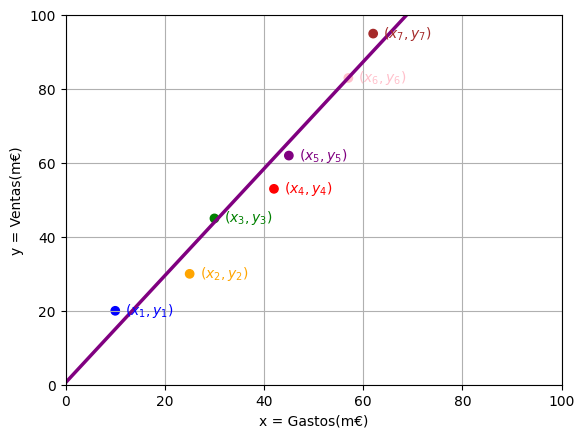

In [18]:
# Representamos los datos.
categories = array([0,1,2,3,4,5,6])
colormap = array(['blue', 'orange', 'green', 'red', 'purple', 'pink', 'brown'])
plt.xlim([0,100])
plt.ylim([0,100])
plt.grid(True)
plt.scatter(gastos,ventas,c = colormap[categories])
plt.xlabel('x = Gastos(m€)')
plt.ylabel('y = Ventas(m€)')
for i in range(size(gastos)):
    plt.text(x=gastos[i]+2, y=ventas[i]-1, s="$(x_"+str(i+1)+",y_"+str(i+1)+")$", fontdict=dict(color=colormap[i], size=10))

# Representamos la recta.

x = linspace(0,100) # crear array de 0 a 100
y = X[0,0]*x - X[1,0] 
plt.plot(x,y,c = 'purple', lw = 2.5) # lw establece el ancho de línea y c='purple' el color
plt.show()

**Ejercicio**
La evolución de la temperatura a lo largo del día sigue la siguiente función periódica 

$$T(t)=c_1+c_2cos(\pi\,t/12)+c_3sin(\pi\,t/12) \qquad t\in \big[0,24\big]$$ 
Dadas las temperaturas tomadas en ciertas horas y proporcionadas en la siguiente tabla, 

| 	| 	| 	|  	|  	| |  	| | 	| 	| 	|  	|  	| |  	| |
|-	|-	|-	|-	|-	|-	|-	|-	|-	|-	|-	|-	|-	|-	|-	|-	|
| Hora del día 	| 0h 	| 1h 	| 2h 	| 3h 	| 4h 	| 5h 	| 6h	| 7h 	| 8h 	| 9h 	| 10h 	| 11h 	| 12h	|
| Temperatura 	| 21|21|20|19|19|19|18|17|18|19|21|23|23|

determinar las constantes $c_1$,$c_2$ y $c_3$ de manera que podamos predecir la temperatura a las 20h. 

In [20]:
# Recta de mínimos cuadrados.
A = zeros((13,3))
for i in range(3):
    if(i == 0):
        A[:, i] = 1
    elif(i == 1):
        for j in range(13):
            A[j,i] = cos(pi* j/12)
    else:
        for j in range(13):
            A[j,i] = sin(pi * j/12)

B = array([[21], [21], [20], [19], [19], [19], [18], [17], [18], [19], [21], [23], [23]])
print("Matriz A = \n", A)
print("\nMatriz B = \n", B)

print("\n A es una matriz de tamaño: ", shape(A), " cuyo rango es: ", matrix_rank(A))
m, n = shape(A)
if(matrix_rank(A) == n):
    print("Estamos en el caso donde el rango A es máximo, luego la solución de At @ A @ X = At @ B es única.\n")
    print("Además, la matriz At@A es definida positiva (y por tanto inversible y simétrica, luego podemos aplicar el método de Cholesky.\n")

exito, C = facto_cholesky(transpose(A)@A)
chol = tril(C)
print("Factorización de Cholesky de la matriz At@A: \n", chol)

exito, Y = descenso(chol, conjugada(A)@B)
exito, X = remonte(transpose(chol),Y)

print("Por tanto, la solución del sistema en el sentido de mínimos cuadrados es: ", X)

print("\n Por tanto, la recta pedida es \n T(t) = ", X[0,0], X[1,0], "*cos(pi/12 * t)", X[1,0], "*sin(pi/12 * t)")

Matriz A = 
 [[ 1.00000000e+00  1.00000000e+00  0.00000000e+00]
 [ 1.00000000e+00  9.65925826e-01  2.58819045e-01]
 [ 1.00000000e+00  8.66025404e-01  5.00000000e-01]
 [ 1.00000000e+00  7.07106781e-01  7.07106781e-01]
 [ 1.00000000e+00  5.00000000e-01  8.66025404e-01]
 [ 1.00000000e+00  2.58819045e-01  9.65925826e-01]
 [ 1.00000000e+00  6.12323400e-17  1.00000000e+00]
 [ 1.00000000e+00 -2.58819045e-01  9.65925826e-01]
 [ 1.00000000e+00 -5.00000000e-01  8.66025404e-01]
 [ 1.00000000e+00 -7.07106781e-01  7.07106781e-01]
 [ 1.00000000e+00 -8.66025404e-01  5.00000000e-01]
 [ 1.00000000e+00 -9.65925826e-01  2.58819045e-01]
 [ 1.00000000e+00 -1.00000000e+00  1.22464680e-16]]

Matriz B = 
 [[21]
 [21]
 [20]
 [19]
 [19]
 [19]
 [18]
 [17]
 [18]
 [19]
 [21]
 [23]
 [23]]

 A es una matriz de tamaño:  (13, 3)  cuyo rango es:  3
Estamos en el caso donde el rango A es máximo, luego la solución de At @ A @ X = At @ B es única.

Además, la matriz At@A es definida positiva (y por tanto inversible y simé

Por tanto, la temperatura a las 20h será de  22.72685853380176  grados.



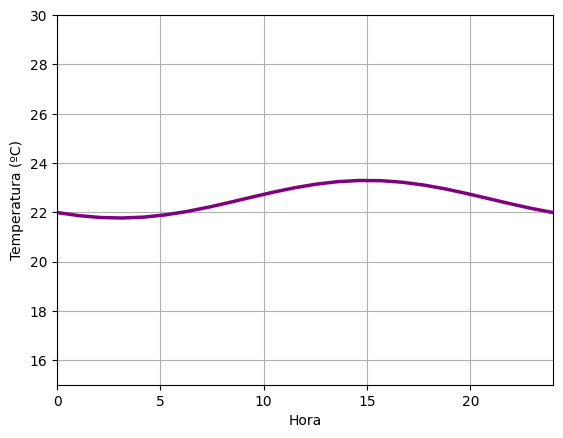

In [21]:
t = 20
T = X[0,0] + X[1,0]*cos(pi/12 * t) + X[1,0]*sin(pi/12 * t)
print("Por tanto, la temperatura a las 20h será de ", T, " grados.\n")

# Representamos los datos 
plt.xlim([0,24])
plt.ylim([15,30])
plt.grid(True)
plt.xlabel('Hora')
plt.ylabel('Temperatura (ºC)')

# Representamos la recta
t = linspace(0,24,24)
y = X[0,0] + X[1,0]*cos(pi/12 * t) + X[1,0]*sin(pi/12 * t)
plt.plot(t,y,c = 'purple', lw = 2.5)
plt.show()